In [47]:
# Q1: Transfer Learning - Segmentation and Detection

In [48]:
import os
import matplotlib.pyplot as plt

from ultralytics import YOLO

In [49]:
# 2. Apply the YOLO26 pretrained detection model (yolo26n.pt) on 5 images from the 
# dataset to detect cats and dogs with bounding boxes and confidence scores.

# load the yolo models
det_model = YOLO("yolov8n.pt") # Detection model
seg_model = YOLO("yolov8n-seg.pt") # Segmentation model

# Path to dataset images folder
images_dir = "TransferLearningImages/images"

# Get first 5 jpg images
image_files = [
    f for f in os.listdir(images_dir)
    if f.endswith(".jpg")
][:5]

# Create output folder
output_folder = "output_results"

os.makedirs(output_folder, exist_ok=True)

print(image_files)

['Abyssinian_1.jpg', 'Abyssinian_10.jpg', 'Abyssinian_100.jpg', 'Abyssinian_101.jpg', 'Abyssinian_102.jpg']


Processing: TransferLearningImages/images\Abyssinian_1.jpg

image 1/1 C:\Users\ceb1003\desktop\notes\VSCode\Program6\TransferLearningImages\images\Abyssinian_1.jpg: 448x640 1 cat, 22.1ms
Speed: 0.9ms preprocess, 22.1ms inference, 0.5ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 C:\Users\ceb1003\desktop\notes\VSCode\Program6\TransferLearningImages\images\Abyssinian_1.jpg: 448x640 1 cat, 29.8ms
Speed: 1.2ms preprocess, 29.8ms inference, 0.8ms postprocess per image at shape (1, 3, 448, 640)
Saved: output_results\result_Abyssinian_1.jpg


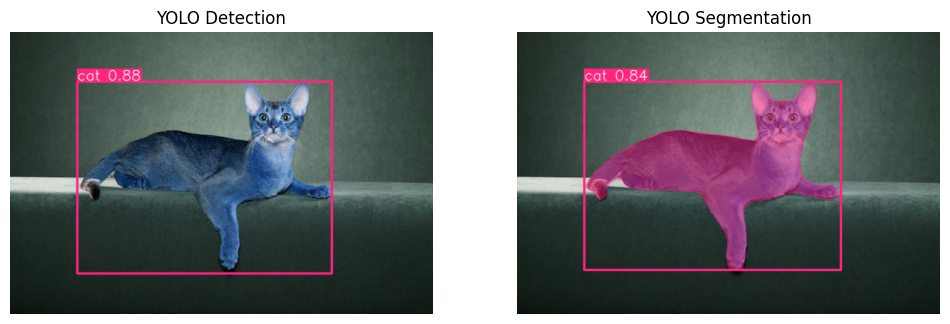

Processing: TransferLearningImages/images\Abyssinian_10.jpg

image 1/1 C:\Users\ceb1003\desktop\notes\VSCode\Program6\TransferLearningImages\images\Abyssinian_10.jpg: 640x480 1 cat, 1 sink, 23.7ms
Speed: 0.9ms preprocess, 23.7ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 C:\Users\ceb1003\desktop\notes\VSCode\Program6\TransferLearningImages\images\Abyssinian_10.jpg: 640x480 1 cat, 32.2ms
Speed: 1.0ms preprocess, 32.2ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 480)
Saved: output_results\result_Abyssinian_10.jpg


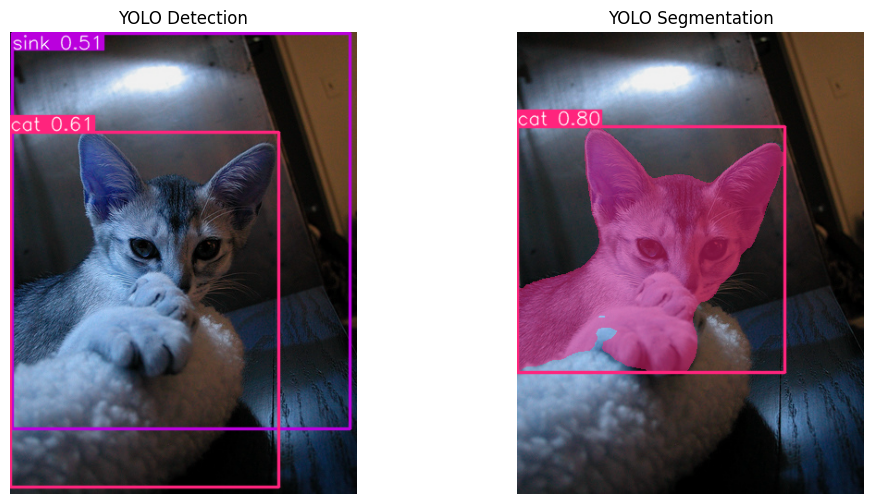

Processing: TransferLearningImages/images\Abyssinian_100.jpg

image 1/1 C:\Users\ceb1003\desktop\notes\VSCode\Program6\TransferLearningImages\images\Abyssinian_100.jpg: 640x512 1 cat, 1 bed, 26.0ms
Speed: 1.1ms preprocess, 26.0ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 512)

image 1/1 C:\Users\ceb1003\desktop\notes\VSCode\Program6\TransferLearningImages\images\Abyssinian_100.jpg: 640x512 1 cat, 1 bed, 35.2ms
Speed: 1.0ms preprocess, 35.2ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 512)
Saved: output_results\result_Abyssinian_100.jpg


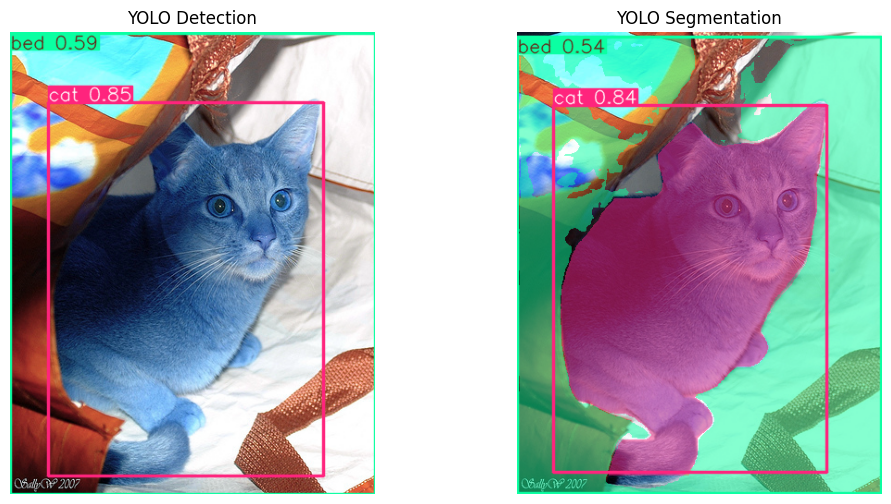

Processing: TransferLearningImages/images\Abyssinian_101.jpg

image 1/1 C:\Users\ceb1003\desktop\notes\VSCode\Program6\TransferLearningImages\images\Abyssinian_101.jpg: 448x640 1 cat, 25.9ms
Speed: 1.0ms preprocess, 25.9ms inference, 0.5ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 C:\Users\ceb1003\desktop\notes\VSCode\Program6\TransferLearningImages\images\Abyssinian_101.jpg: 448x640 1 cat, 35.8ms
Speed: 1.0ms preprocess, 35.8ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)
Saved: output_results\result_Abyssinian_101.jpg


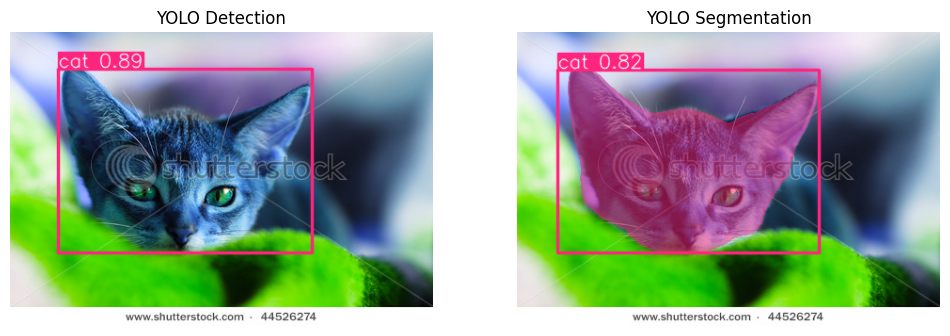

Processing: TransferLearningImages/images\Abyssinian_102.jpg

image 1/1 C:\Users\ceb1003\desktop\notes\VSCode\Program6\TransferLearningImages\images\Abyssinian_102.jpg: 608x640 1 cat, 37.6ms
Speed: 4.9ms preprocess, 37.6ms inference, 0.7ms postprocess per image at shape (1, 3, 608, 640)

image 1/1 C:\Users\ceb1003\desktop\notes\VSCode\Program6\TransferLearningImages\images\Abyssinian_102.jpg: 608x640 1 cat, 49.8ms
Speed: 3.6ms preprocess, 49.8ms inference, 1.6ms postprocess per image at shape (1, 3, 608, 640)
Saved: output_results\result_Abyssinian_102.jpg


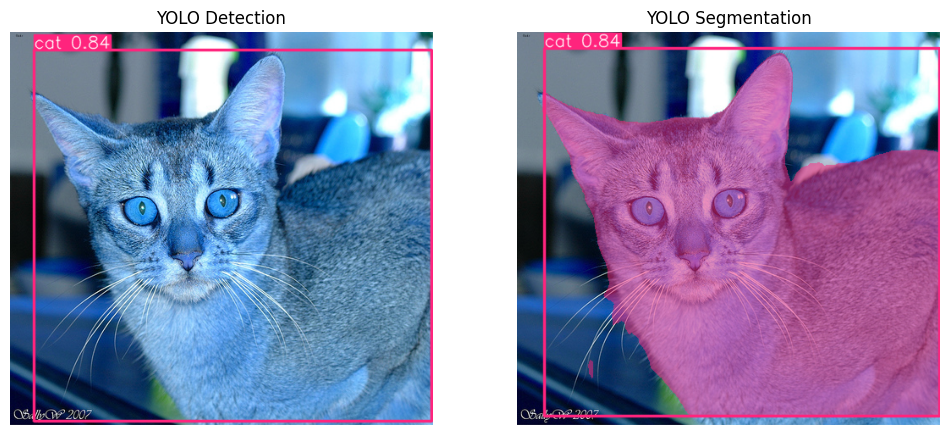

In [50]:
# 3. Apply the YOLO26 pretrained segmentation model (yolo26n-seg.pt) on the same 5
# images to generate pixel-level instance segmentation masks.

# Process each image
for file in image_files:

    # Create full image path
    image_path = os.path.join(images_dir, file)

    print("Processing:", image_path)

    # Detection
    detection_results = det_model(image_path)
    # detection output
    detection_results[0].show()
    # detection image
    detection_image = detection_results[0].plot()    

    # Segmentation
    segmentation_results = seg_model(image_path)
    # segmentation output
    segmentation_results[0].show()
    # segmentation image
    segmentation_image = segmentation_results[0].plot()

# 4. Visualize and save the annotated output images 
# showing both detection and segmentation results side by side for each of the 5 images.

    plt.figure(figsize=(12,6))

    # left side is detection
    plt.subplot(1, 2, 1)

    plt.imshow(detection_image[:, :, ::-1])  # BGR -> RGB

    plt.title("YOLO Detection")

    plt.axis("off")

    # right side is Segmentation
    plt.subplot(1, 2, 2)

    plt.imshow(segmentation_image[:, :, ::-1])  # BGR -> RGB

    plt.title("YOLO Segmentation")

    plt.axis("off")

# Save the output
    save_path = os.path.join(
        output_folder,
        f"result_{file}"
    )

    plt.savefig(save_path)

    print("Saved:", save_path)

    plt.show()

In [51]:
# 5. Analyze and interpret the results by explaining the bounding boxes, confidence scores, 
#segmentation masks, and how well the pretrained YOLO26 model performs on pet images.

# The pretrained YOLOv8 detection and segmentation models successfully identified cats and dogs in the Oxford-IIIT Pet Dataset. 
# The detection model generated accurate bounding boxes with high confidence scores
# while the segmentation model produced detailed pixel-level masks around pets. 
# Overall, the pretrained YOLO models performed well because
# they were trained on large-scale datasets containing similar
# object categories such as cats and dogs.